In this guide, we'll plot 'Swasthya Sathi Active Public Hospital details per District in West Bengal' in West Bengal map using geopandas. 


We need following packages for this code to work: pandas, matplotlib and geopandas.

We have used this [Shapefile](https://knorish-cdn.azureedge.net/public/97abe19e-7653-49c0-96d2-c56dfe049a4c/customfile/17092021/aee65.zip) to plot the map of West Bengal with district boundaries.


Our objective is to visualize aavailability of Public Hospitals per district in West Bengal with access of 'Swasthya Sathi' scheme. Hospital list data was sourced from this [link](https://helpline.swasthyasathi.gov.in/ssHospitalDdetails.aspx).

**Step 0: We are specifying path of our Input files**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/wb-shapefile/West_Bengal/District_shape_West_Bengal.prj
/kaggle/input/wb-shapefile/West_Bengal/District_shape_West_Bengal.sbx
/kaggle/input/wb-shapefile/West_Bengal/District_shape_West_Bengal.dbf
/kaggle/input/wb-shapefile/West_Bengal/District_shape_West_Bengal.cpg
/kaggle/input/wb-shapefile/West_Bengal/District_shape_West_Bengal.shp
/kaggle/input/wb-shapefile/West_Bengal/District_shape_West_Bengal.shx
/kaggle/input/wb-shapefile/West_Bengal/District_shape_West_Bengal.sbn
/kaggle/input/public-hospital-list-wb/public_hospital_list_wb.xlsx


**Step 1: import all necessary libraries**

In [2]:
import pandas as pd 
import geopandas as gpd
import matplotlib.pyplot as plt
import os

**Step 2: Read the Data source**

In [3]:
hospital_data_df = pd.read_excel('/kaggle/input/public-hospital-list-wb/public_hospital_list_wb.xlsx') #Data source https://helpline.swasthyasathi.gov.in/ssHospitalDdetails.aspx
print(hospital_data_df.head())

    District               Public_Hospital_Name
0  Darjiling   KURSEONG SUB DIVISIONAL HOSPITAL
1  Kalimpong  KALIMPONG SUB DIVISIONAL HOSPITAL
2  Darjiling                    PHANSIDEWA BPHC
3  Darjiling           NAXALBARI RURAL HOSPITAL
4  Darjiling           KHARIBARI RURAL HOSPITAL


**Step 3: Read the shapefile**

In [4]:
shp_gdf = gpd.read_file('/kaggle/input/wb-shapefile/West_Bengal/District_shape_West_Bengal.shp')
print('Current CRS= ',shp_gdf.crs)

Current CRS=  EPSG:4326


**Step 4: Change CRS for better centroid calculation**

In [5]:
shp_gdf_3857 = shp_gdf.to_crs(epsg=3857)
print('Current CRS= ',shp_gdf_3857.crs)

Current CRS=  EPSG:3857


**Step 5: Our Hospital List data doesn't have Count specific to District. So, lets create the data.**

In [6]:
hospital_count_df = hospital_data_df[['District']].value_counts().reset_index(name='Public_Hospital_Count')
print(hospital_count_df.head())

            District  Public_Hospital_Count
0  South 24 Parganas                     43
1  North 24 Parganas                     42
2              Nadia                     38
3        Murshidabad                     32
4            Bankura                     31


**Step 6: Now we can merge our ShapeFile DataFrame and Hospital count DataFrame based on 'District' name.**

In [7]:
merged = shp_gdf_3857.set_index('NAME').join(hospital_count_df.set_index('District'))
print(merged.head())

                             GM_LAYER NAME_0       NAME_1  \
NAME                                                        
Jhargram            Unknown Area Type  India  West Bengal   
Kalimpong           Unknown Area Type  India  West Bengal   
Kolkata             Unknown Area Type  India  West Bengal   
Paschim Barddhaman  Unknown Area Type  India  West Bengal   
Pashchim Medinipur  Unknown Area Type  India  West Bengal   

                                                             geometry  \
NAME                                                                    
Jhargram            POLYGON ((9692869.997 2598788.654, 9693299.743...   
Kalimpong           POLYGON ((9844199.176 3133671.511, 9845053.573...   
Kolkata             POLYGON ((9841456.786 2578468.689, 9841277.583...   
Paschim Barddhaman  POLYGON ((9748824.450 2695961.054, 9748956.091...   
Pashchim Medinipur  POLYGON ((9783344.261 2574314.220, 9783711.159...   

                    Public_Hospital_Count  
NAME            

**Step 7: Now, we can plot the Map and color code it based on Hospital count.**

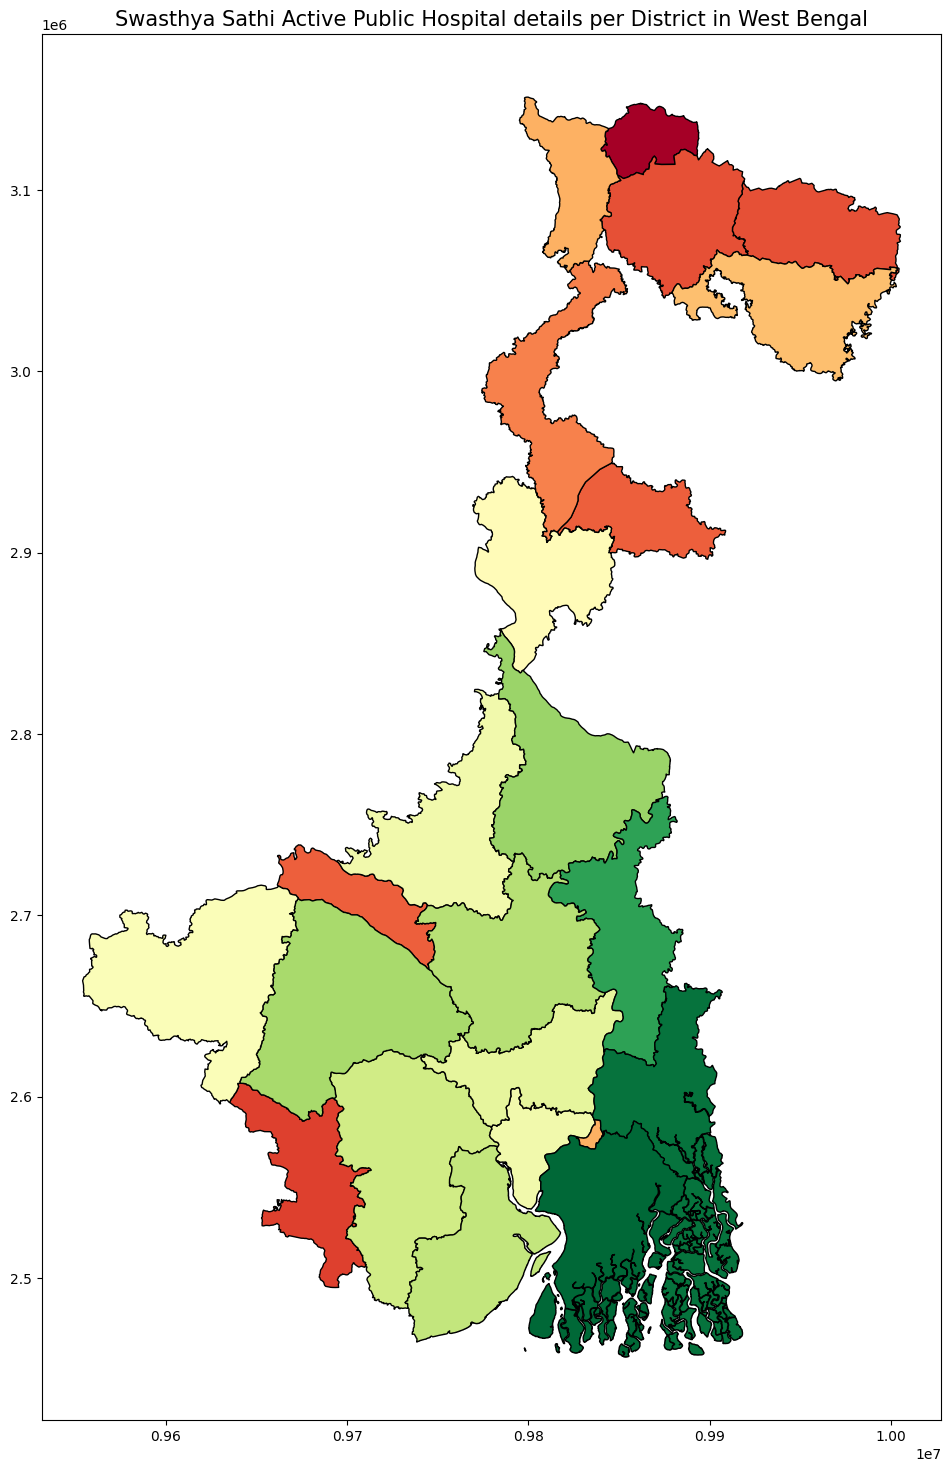

In [8]:
fig, ax = plt.subplots(1, figsize=(18, 18))
ax.axis('on')
ax.set_title('Swasthya Sathi Active Public Hospital details per District in West Bengal', fontdict={'fontsize': '15', 'fontweight' : '3'})
fig = merged.plot(column='Public_Hospital_Count', 
                  cmap ='RdYlGn',#RedYellowGreen 
                  linewidth = 1, #Borders
                  ax = ax, #ax = argument
                  edgecolor ='0',#0 = Black
                 )
                  #legend=True)

**Step 8: Now, we add District names and Hospital count at the centre points of each district on top of this Map**

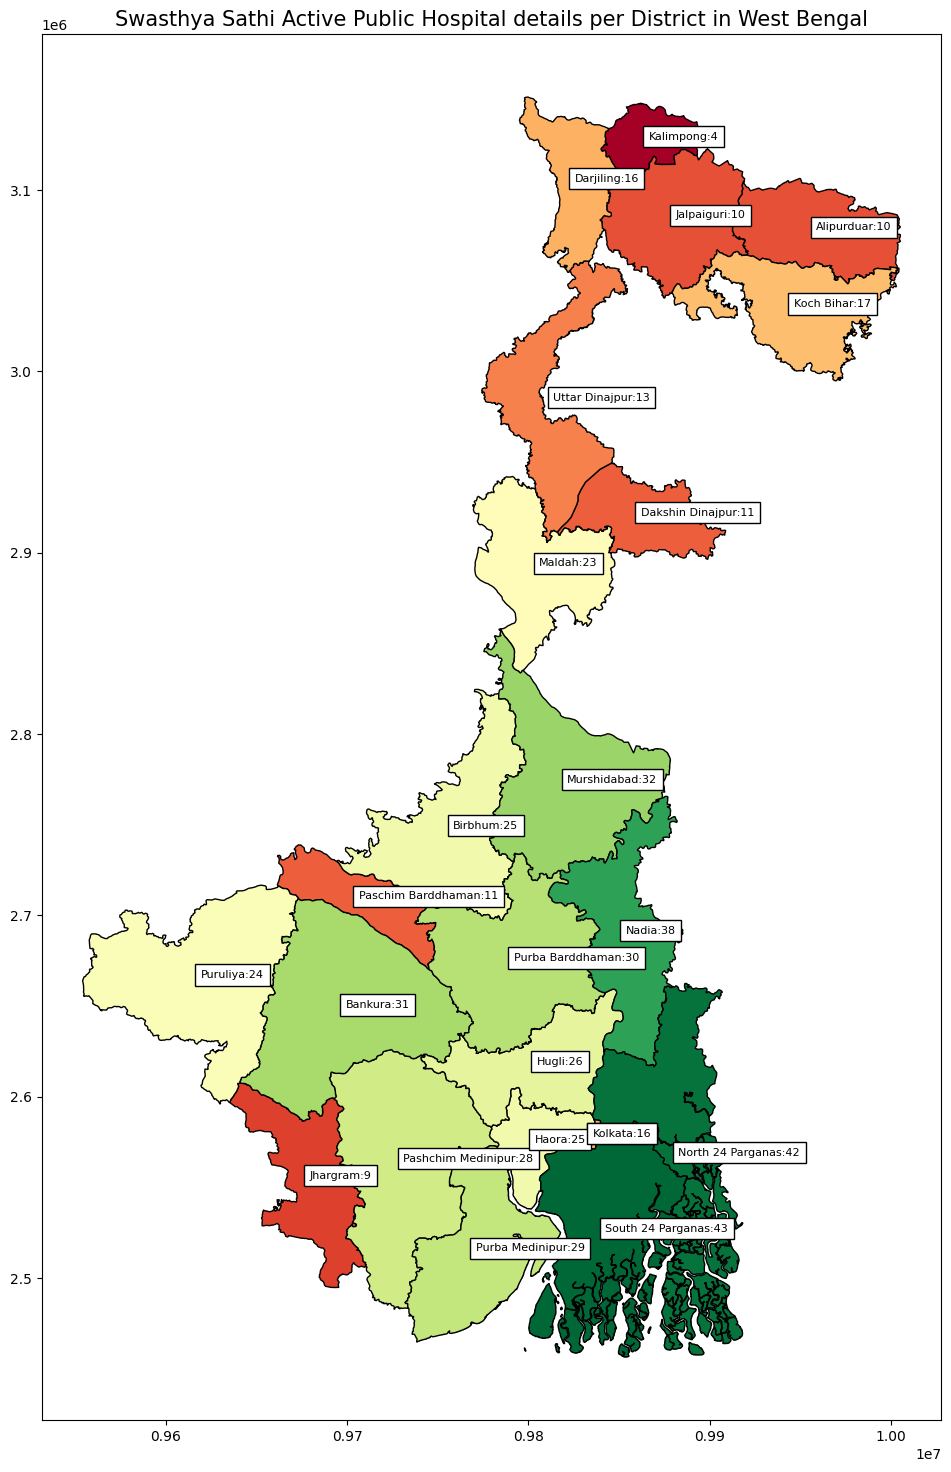

In [9]:
fig, ax = plt.subplots(1, figsize=(18, 18))
ax.axis('on')
ax.set_title('Swasthya Sathi Active Public Hospital details per District in West Bengal', fontdict={'fontsize': '15', 'fontweight' : '3'})
fig = merged.plot(column='Public_Hospital_Count', 
                  cmap ='RdYlGn',#RedYellowGreen 
                  linewidth = 1, #Borders
                  ax = ax, #ax = argument
                  edgecolor ='0',#0 = Black
                 )

merged2 = merged.copy()
merged2['center'] = merged2['geometry'].centroid
merged_shape_points = merged2.copy()
merged_shape_points.set_geometry("center", inplace = True)
texts = []

for x, y, label, cnt in zip(merged_shape_points.geometry.x, merged_shape_points.geometry.y, shp_gdf_3857['NAME'], merged_shape_points['Public_Hospital_Count']):
    texts.append(plt.text(x, y, str(label) + ':' + str(cnt), fontsize = 8, color='black',  bbox=dict(facecolor='white', edgecolor='black')))


Final Thoughts: As we can see from this Map, Number of Hospital is more in Kolkata and it's nearby region. Number of Hospitals should be much more in the North Bengal region.

If you want to know more in depth, please go through this [code](https://www.kaggle.com/code/eddyctid/data-visualization-on-indian-map-using-python).

Please Upvote this if you found it helpful and feel free to share in your network.